# Model Interpretation

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

#Creating feature and target arrays
X = housing.data
y = housing.target

df_X = pd.DataFrame(X,columns=housing.feature_names)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=False).fit(X)
scaler.transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42)

In [7]:
X

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

In [2]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf = RandomForestRegressor(n_estimators=100, max_depth=3)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=3)

In [4]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, rf.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, rf.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, rf.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, rf.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, rf.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, rf.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, rf.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, rf.predict(X_test))))

MAE train:  0.5682547469944138
MSE train:  0.5779573120443283
RMSE train:  0.7602350373695811
r2:  0.754049530128101
MAE test:  0.5785924002604564
MSE test:  0.5914472849081513
RMSE test:  0.7690560999746061
r2:  0.741206629211719


/tmp/ipykernel_10864/1798828518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=housing.feature_names, y=rf.feature_importances_, palette="Blues_d")


<Axes: >

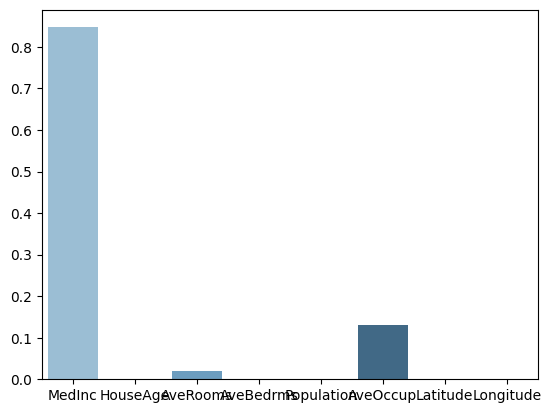

In [5]:
import seaborn as sns
sns.barplot(x=housing.feature_names, y=rf.feature_importances_, palette="Blues_d")

In [6]:
#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(alpha=30, hidden_layer_sizes=(20,10,5), max_iter=5000, solver='sgd')
mlp.fit(X_train,y_train)

y_train_pred= mlp.predict(X_train)
y_test_pred= mlp.predict(X_test)

from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train,y_train_pred))
print("MSE train: ",metrics.mean_squared_error(y_train,y_train_pred))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print("r2: ",metrics.r2_score(y_train, y_train_pred))

print("MAE test: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("MSE test: ",metrics.mean_squared_error(y_test, y_test_pred))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print("r2: ",metrics.r2_score(y_test, y_test_pred))

MAE train:  0.598592213211919
MSE train:  0.6269912315249213
RMSE train:  0.7918277789550713
r2:  0.5319899125859222
MAE test:  0.5929887189570967
MSE test:  0.6163107607433841
RMSE test:  0.7850546227769021
r2:  0.5304442454182241


## LIME: Local Interpretable Model-Agnostic Explanations

![lime](https://www.oreilly.com/content/wp-content/uploads/sites/2/2019/06/figure4-99d9ea184dd35876e0dbae81f6fce038.jpg)

ref: Marco Tulio Ribeiro, Sameer Singh and Carlos Guestrin. Why Should {I} Trust You?: Explaining the Predictions of Any Classifier. SIGKDD16.

In [10]:
# Install the package in the current Jupyter kernel
import sys
# !conda config --append channels conda-forge
# !conda install --yes --prefix {sys.prefix} lime
!{sys.executable} -m pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9bff9397c90d0636ea618ea7487ad9dc7c047d362654c26d8fb8973a08c29902
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [24]:
import lime
import lime.lime_tabular

In [12]:
housing.feature_names
# CATEGORICAL: None for California Housing Dataset

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [13]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=housing.feature_names, verbose=True, mode='regression')

In [14]:
y_train[:11]

array([1.938  , 1.697  , 2.598  , 1.361  , 5.00001, 2.813  , 2.161  ,
       1.174  , 5.00001, 1.042  , 1.281  ])

In [15]:
i = 0
exp = explainer.explain_instance(X_train[i], rf.predict, num_features=5)
#explaination of the random forest for the first observation.

Intercept 2.226644166213297
Prediction_local [1.976062]
Right: 1.9136240514954879


In [16]:
exp.show_in_notebook(show_table=True)


In [17]:
exp_mlp = explainer.explain_instance(X_train[i], mlp.predict, num_features=5)

Intercept 1.9836902820976958
Prediction_local [2.37380535]
Right: 2.2561931551774133


In [18]:
exp_mlp.show_in_notebook(show_table=True)

In [19]:
i = 10
exp = explainer.explain_instance(X_train[i], rf.predict, num_features=5)
exp.show_in_notebook(show_table=True)

Intercept 2.3438681069172933
Prediction_local [1.58788973]
Right: 1.5329425713073725


In [20]:
exp_mlp = explainer.explain_instance(X_train[i], mlp.predict, num_features=5)
exp_mlp.show_in_notebook(show_table=True)

Intercept 2.1346727201941955
Prediction_local [1.97554868]
Right: 1.9571630198379122


## SHAP: SHapley Additive exPlanations

$$\phi_j(val)=\sum_{S\subseteq\{x_{1},\ldots,x_{p}\}\setminus\{x_j\}}\frac{|S|!\left(p-|S|-1\right)!}{p!}\left(val\left(S\cup\{x_j\}\right)-val(S)\right)$$

In [21]:
# Install the package in the current Jupyter kernel
import sys
#!conda install --yes --prefix {sys.prefix} shap
!{sys.executable} -m pip install shap

In [22]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

df_X_train=pd.DataFrame(X_train,columns=housing.feature_names)

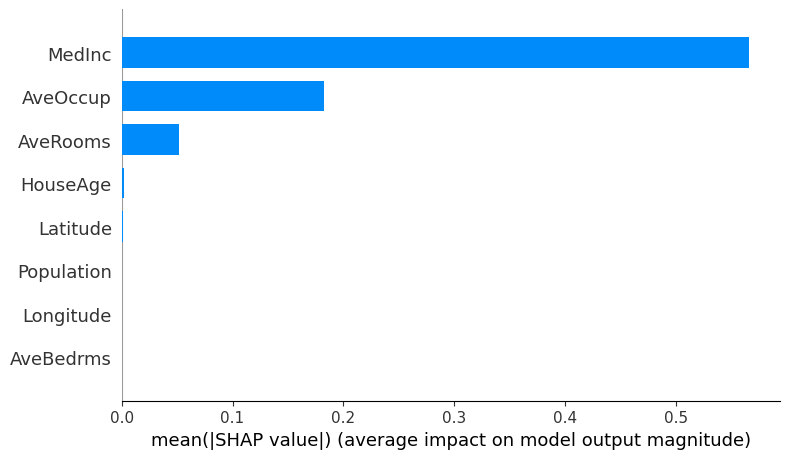

In [25]:
import shap

shap.initjs()

explainer_rf = shap.TreeExplainer(rf)
shap_values = explainer_rf.shap_values(df_X_train)

shap.summary_plot(shap_values, df_X_train, plot_type="bar")

## Gráfico de Resumen (Beeswarm Plot)
Este gráfico te da una visión general de la importancia de cada característica para todo el conjunto de datos y cómo sus valores afectan las predicciones. Observa lo siguiente:

*   Eje Y: Muestra las características ordenadas por su importancia global (de arriba hacia abajo).
*   Eje X: Representa el valor SHAP de la característica. Un valor SHAP positivo significa que la característica empuja la predicción del modelo hacia un valor más alto, mientras que un valor negativo la empuja hacia un valor más bajo.

Colores de los puntos: El color (generalmente de azul a rojo) indica el valor real de la característica para esa observación. Por ejemplo:
*   Rojo (o tonos cálidos) a menudo indica un valor alto de la característica.
*   Azul (o tonos fríos) a menudo indica un valor bajo de la característica.

Dispersión de los puntos: Cada punto representa la explicación SHAP para una única instancia en el conjunto de datos. La densidad vertical te muestra dónde se agrupan los efectos.
Interpretación clave: Puedes ver qué características son más influyentes (las de arriba). Además, el color te indica si un valor alto o bajo de esa característica tiende a aumentar o disminuir la predicción del modelo. Por ejemplo, si ves muchos puntos rojos a la derecha para 'MedInc', significa que un ingreso medio alto tiende a aumentar el valor predicho de la vivienda.


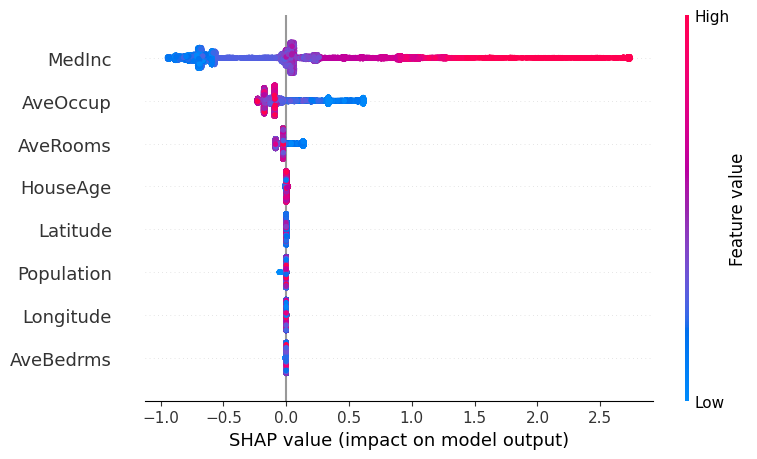

In [26]:
shap.summary_plot(shap_values, df_X_train)

In [27]:
i=0

expected_value = shap_values[i,-1]

shap.force_plot(expected_value, shap_values[i,:], df_X_train.iloc[i,:])

In [28]:
shap.force_plot(expected_value, shap_values[i,:], df_X_train.iloc[i,:])

In [ ]:
 shap.force_plot(explainer_rf.expected_value,shap_values,features=X_train,feature_names=df_X_train.columns)

  0%|          | 0/14448 [00:00<?, ?it/s]

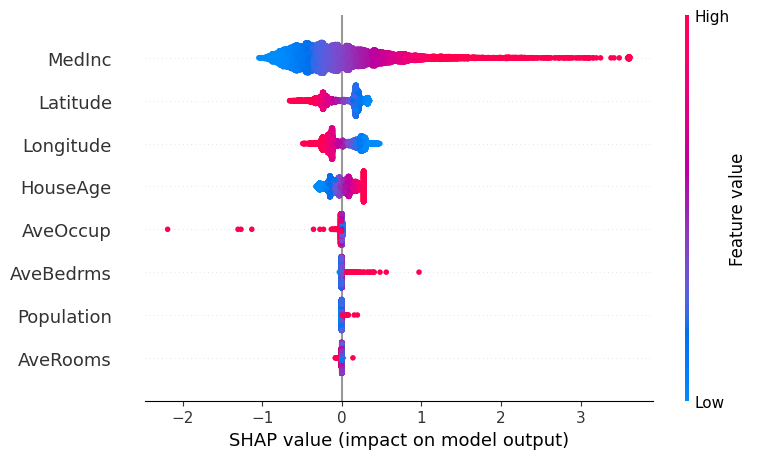

In [29]:
X_train_summary = shap.kmeans(X_train, 20)
# explain all the predictions in the test set
explainer = shap.KernelExplainer(mlp.predict, X_train_summary)
shap_values = explainer.shap_values(df_X_train)
shap.summary_plot(shap_values, df_X_train)